# 复现 walkthrough（turtle 数据集）

本 notebook 与 `reproduce_walkthrough.ipynb`（umineko 数据集）结构完全一致，
但目标换成 **turtle 数据集**，并**保留每一步的中间结果**：数据形状、标签分布、
数据切分、模型结构、20 轮主动学习的逐轮指标、指标曲线，以及 UMAP / 标签传播 /
时序标签等可视化。

turtle 与 umineko 的差异：
- 数据 `(N, 3, 200)`：仅 3 轴加速度（无气压通道），窗口长度 200（umineko 为 50）。
- 7 个行为类别（0..6），-1 表示 unknown。

代码复用 `reproduce/` 下的 turtle 模块（`turtle_data` / `turtle_model`）与通用的
`train_eval`。

## 0. 环境与随机种子

In [1]:
import os, sys, random, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

HERE = os.path.abspath('.')
sys.path.insert(0, HERE)

from turtle_data import (load_data, build_splits, data_loader_turtle,
                         labeldict_findstr, label_colors,
                         labeldict_wounknown_findstr, NUM_CLASSES)
from turtle_model import TurtleNN, SupContrastiveLoss, freeze_encoders
from data_preprocessing import majority_value
from train_eval import (train_model, evaluate_model, evaluate_supContrast_model,
                        unfreeze_encoders, unfreeze_all,
                        uncertainty_sampling, AE_eval_time_series)

def set_random_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 2025
set_random_seed(SEED)
device = 'cpu'
print('torch', torch.__version__, '| device', device, '| seed', SEED)

torch 2.8.0 | device cpu | seed 2025


## 1. 数据读取与预处理

加载 `data/turtle/data.npy` 与 `label.npy`，对每个窗口的逐帧标签做多数投票
（turtle 无 foraging 重映射；-1 即 unknown）。

In [2]:
DATA = os.path.normpath(os.path.join(HERE, '..', 'data', 'turtle', 'data.npy'))
LABEL = os.path.normpath(os.path.join(HERE, '..', 'data', 'turtle', 'label.npy'))
data_b, label_b, vote_label = load_data(DATA, LABEL)
print('data_b :', data_b.shape, data_b.dtype, '  (N, channels=3accel, win_len=200)')
print('label_b:', label_b.shape, '  (per-timestep labels)')
print('vote_label:', vote_label.shape)

data_b : (15619, 3, 200) float64   (N, channels=3accel, win_len=200)
label_b: (15619, 200)   (per-timestep labels)
vote_label: (15619,)


In [3]:
# 投票后标签分布
uniq, cnt = np.unique(vote_label, return_counts=True)
dist = pd.DataFrame({'label': uniq,
                     'name': [labeldict_findstr.get(int(u), str(u)) for u in uniq],
                     'count': cnt})
dist

,label,name,count
0,-1,unknown,6
1,0,Resting,2819
2,1,Swimming,10222
3,2,Stay in surface,1396
4,3,Gliding,497
5,4,Feeding,210
6,5,Scratching,63
7,6,Breathing,406


### 1.1 训练/测试切分 + labeled/unlabeled 切分

In [4]:
splits = build_splits(data_b, vote_label)
X_labeled, y_labeled   = splits['X_labeled'],   splits['y_labeled']
X_unlabeled, y_unlabeled = splits['X_unlabeled'], splits['y_unlabeled']
X_test, y_test         = splits['X_test'],      splits['y_test']
X_train_full           = splits['X_train_full']

print('X_labeled  :', X_labeled.shape)
print('X_unlabeled:', X_unlabeled.shape)
print('X_test     :', X_test.shape)

X_labeled  : (124, 3, 200)
X_unlabeled: (12366, 3, 200)
X_test     : (3123, 3, 200)


In [5]:
# 初始 labeled 集合的类别分布
u, c = np.unique(y_labeled, return_counts=True)
pd.DataFrame({'label': u, 'name': [labeldict_findstr[int(i)] for i in u], 'count': c})

,label,name,count
0,0,Resting,22
1,1,Swimming,83
2,2,Stay in surface,13
3,3,Gliding,3
4,4,Feeding,1
5,6,Breathing,2


## 2. 模型

`TurtleNN`：3 轴加速度走单个 `Encoder3d4`，窗口 200 经三次 /2 池化得到 25，
特征维 128*25=3200；Linear 到 32 维共享嵌入；再分出 projector(对比学习 16 维)
与 classifier(7 类)。

In [6]:
model = TurtleNN(number_classes=NUM_CLASSES).to(device)
classify_criterion = nn.CrossEntropyLoss()
supContrast_criterion = SupContrastiveLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {n_params:,}')
print(model)

总参数量: 229,783
TurtleNN(
  (acc_encoder): Encoder3d4(
    (conv1): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (fc): Linear(in_features=768, out_features=64, bias=True)
  )
  (linear): Linear(in_features=3200, out_features=32, bias=True)
  (projector): Sequential(
    (0): Linear(in_features=3

In [7]:
# 单次前向，确认各阶段张量形状
model.eval()
with torch.no_grad():
    sample = torch.tensor(X_labeled[:4]).float()
    proj_out, feat32 = model(sample, if_contrast=True)
    clf_out, _       = model(sample, if_contrast=False)
print('共享32维特征 :', tuple(feat32.shape))
print('projector输出 :', tuple(proj_out.shape))
print('classifier输出:', tuple(clf_out.shape), '(softmax over 7类)')

共享32维特征 : (4, 32)
projector输出 : (4, 16)
classifier输出: (4, 7) (softmax over 7类)


## 3. 主动学习训练循环（20 轮）

每轮三阶段：①监督对比 warm-up（解冻编码器，10 epoch）②冻结编码器训练分类器（50 epoch）
③全解冻再训分类头（50 epoch）。随后在测试集评估，并用**熵不确定性采样**新增 1% 样本。

下方每轮都会打印训练/测试的 Accuracy、Macro-F1、Micro-F1（中间结果全部保留）。

In [8]:
set_random_seed(SEED)  # 重置以保证可复现
model = TurtleNN(number_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

max_iter, warmup, batch_size = 20, 20, 4000
update_size = max(int(0.01 * len(X_train_full)), 2)

metrics, loss_list, selected_labels_list = [], [], []
weight_list = []
iteration = 1
while len(X_unlabeled) > 0:
    print(f'============== Iteration {iteration} ==============')
    print(f'labeled={len(X_labeled)}  unlabeled={len(X_unlabeled)}')

    labeled_loader = DataLoader(
        data_loader_turtle(X_labeled.astype(float), y_labeled.astype(int)),
        batch_size=batch_size, shuffle=True, drop_last=False)

    # stage 1: supervised contrastive warm-up
    unfreeze_encoders(model)
    if iteration < warmup:
        model, _ = train_model(model, labeled_loader, supContrast_criterion,
                               optimizer, epochs=10, device=device, if_contrast=True)
    # stage 2: classifier-only
    freeze_encoders(model)
    model, _ = train_model(model, labeled_loader, classify_criterion,
                           optimizer, epochs=50, device=device, if_contrast=False)
    # stage 3: unfreeze all
    unfreeze_all(model)
    model, avg_loss = train_model(model, labeled_loader, classify_criterion,
                                  optimizer, epochs=50, device=device, if_contrast=False)
    loss_list.append(np.average(avg_loss))

    print('-- Train --')
    tr_acc, tr_macro, tr_micro, _, _ = evaluate_model(model, labeled_loader, device)
    test_loader = DataLoader(
        data_loader_turtle(X_test.astype(float), y_test.astype(int)),
        batch_size=batch_size, shuffle=False, drop_last=False)
    print('-- Test --')
    te_acc, te_macro, te_micro, _, _, _ = evaluate_supContrast_model(
        model, test_loader, cal_threshold=0.5, device=device)

    metrics.append(dict(iteration=iteration, labeled_samples=len(X_labeled),
                        train_acc=tr_acc, train_macro_f1=tr_macro, train_micro_f1=tr_micro,
                        test_acc=te_acc, test_macro_f1=te_macro, test_micro_f1=te_micro))
    weight_list.append({k: v.clone() for k, v in model.state_dict().items()})

    select_size = min(update_size, len(X_unlabeled))
    X_labeled, y_labeled, X_unlabeled, y_unlabeled, sel = uncertainty_sampling(
        X_labeled, y_labeled, X_unlabeled, y_unlabeled, model, select_size, device)
    selected_labels_list.append(sel)

    iteration += 1
    if iteration == max_iter + 1:
        break
print('训练循环完成')

============== Iteration 1 ==============
labeled=124  unlabeled=12366
-- Train --
Accuracy: 0.82, Macro F1 Score: 0.38, Micro F1 Score: 0.82
-- Test --
Accuracy: 0.63, Macro F1 Score: 0.17, Micro F1 Score: 0.63
Labeled samples: 248
============== Iteration 2 ==============
labeled=248  unlabeled=12242
-- Train --
Accuracy: 0.76, Macro F1 Score: 0.27, Micro F1 Score: 0.76
-- Test --
Accuracy: 0.64, Macro F1 Score: 0.16, Micro F1 Score: 0.64
Labeled samples: 372
============== Iteration 3 ==============
labeled=372  unlabeled=12118
-- Train --
Accuracy: 0.77, Macro F1 Score: 0.26, Micro F1 Score: 0.77
-- Test --
Accuracy: 0.66, Macro F1 Score: 0.16, Micro F1 Score: 0.66
Labeled samples: 496
============== Iteration 4 ==============
labeled=496  unlabeled=11994
-- Train --
Accuracy: 0.71, Macro F1 Score: 0.24, Micro F1 Score: 0.71
-- Test --
Accuracy: 0.66, Macro F1 Score: 0.17, Micro F1 Score: 0.66
Labeled samples: 620
============== Iteration 5 ==============
labeled=620  unlabeled=118

## 4. 逐轮指标汇总

In [9]:
df = pd.DataFrame(metrics)
df

,iteration,labeled_samples,train_acc,train_macro_f1,train_micro_f1,test_acc,test_macro_f1,test_micro_f1
0,1,124,0.822581,0.380492,0.822581,0.630239,0.169075,0.630239
1,2,248,0.762097,0.274128,0.762097,0.642102,0.158270,0.642102
2,3,372,0.771505,0.264368,0.771505,0.660263,0.164238,0.660263
3,4,496,0.711694,0.243258,0.711694,0.661864,0.170226,0.661864
4,5,620,0.769355,0.255890,0.769355,0.672751,0.171395,0.672751
5,6,744,0.719086,0.236242,0.719086,0.672110,0.169790,0.672110
6,7,868,0.697005,0.226726,0.697005,0.680435,0.170179,0.680435
7,8,992,0.703629,0.227181,0.703629,0.688441,0.174029,0.688441
8,9,1116,0.718638,0.233793,0.718638,0.692283,0.174715,0.692283
9,10,1240,0.703226,0.236348,0.703226,0.693244,0.175513,0.693244


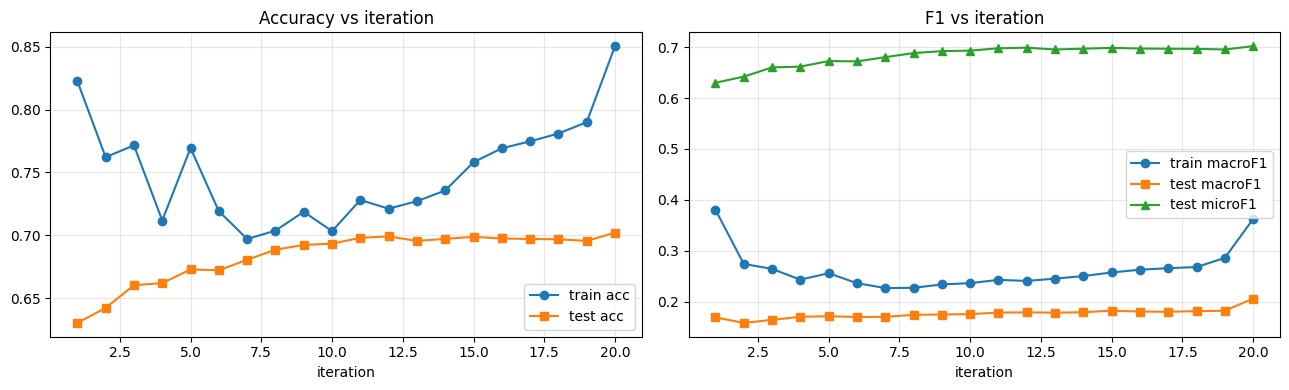

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df.iteration, df.train_acc, 'o-', label='train acc')
axes[0].plot(df.iteration, df.test_acc, 's-', label='test acc')
axes[0].set_title('Accuracy vs iteration'); axes[0].set_xlabel('iteration')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(df.iteration, df.train_macro_f1, 'o-', label='train macroF1')
axes[1].plot(df.iteration, df.test_macro_f1, 's-', label='test macroF1')
axes[1].plot(df.iteration, df.test_micro_f1, '^-', label='test microF1')
axes[1].set_title('F1 vs iteration'); axes[1].set_xlabel('iteration')
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. 可视化中间结果

构造 combined 集合（labeled 窗口 + 录音切片 [3000:6000]，该区间覆盖全部 7 类），
过模型取 32 维特征，UMAP 投影到 2 维；再用 `LabelSpreading` 做标签传播。下面把
UMAP 散点（真值 / 预测 / 传播标签）直接画在 notebook 中。

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading
from umap import UMAP

startloc, endloc = 3000, 6000
combinedata = np.concatenate([X_labeled, data_b[startloc:endloc]])
combinelabel_true = np.concatenate([y_labeled, vote_label[startloc:endloc]])

loader = DataLoader(data_loader_turtle(combinedata.astype(float), combinelabel_true.astype(int)),
                    batch_size=batch_size, shuffle=False, drop_last=False)
repres_list, _, pred_list, label_list = AE_eval_time_series(loader, model, device)

repre = np.concatenate(repres_list).reshape(len(combinedata), -1).astype(float)
proj = UMAP(n_components=2, random_state=SEED).fit_transform(repre)
all_labels = np.concatenate(label_list)
predictions = np.argmax(np.concatenate(pred_list), axis=1)
print('combined:', combinedata.shape, '| UMAP proj:', proj.shape)

/Users/cassie/Documents/code/EIDER/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


combined: (5604, 3, 200) | UMAP proj: (5604, 2)


In [12]:
# 标签传播：把追加的录音切片标记为 -1(未知)，从已知 labeled 点扩散
combineunlabel = np.concatenate([y_labeled, np.full(vote_label[startloc:endloc].shape, -1)])
loader2 = DataLoader(data_loader_turtle(combinedata.astype(float), combineunlabel.astype(int)),
                     batch_size=batch_size, shuffle=False, drop_last=False)
_, _, _, unlabel_list = AE_eval_time_series(loader2, model, device)
all_labels_before = np.concatenate(unlabel_list)

data_umap = StandardScaler().fit_transform(proj)
ls = LabelSpreading(kernel='knn', n_neighbors=10, alpha=0.2)
ls.fit(data_umap, all_labels_before)
propagated_labels = ls.transduction_
u, c = np.unique(propagated_labels, return_counts=True)
pd.DataFrame({'label': u, 'name': [labeldict_findstr.get(int(i), str(i)) for i in u], 'count': c})

,label,name,count
0,0,Resting,1705
1,1,Swimming,3069
2,2,Stay in surface,423
3,3,Gliding,231
4,4,Feeding,66
5,5,Scratching,19
6,6,Breathing,91


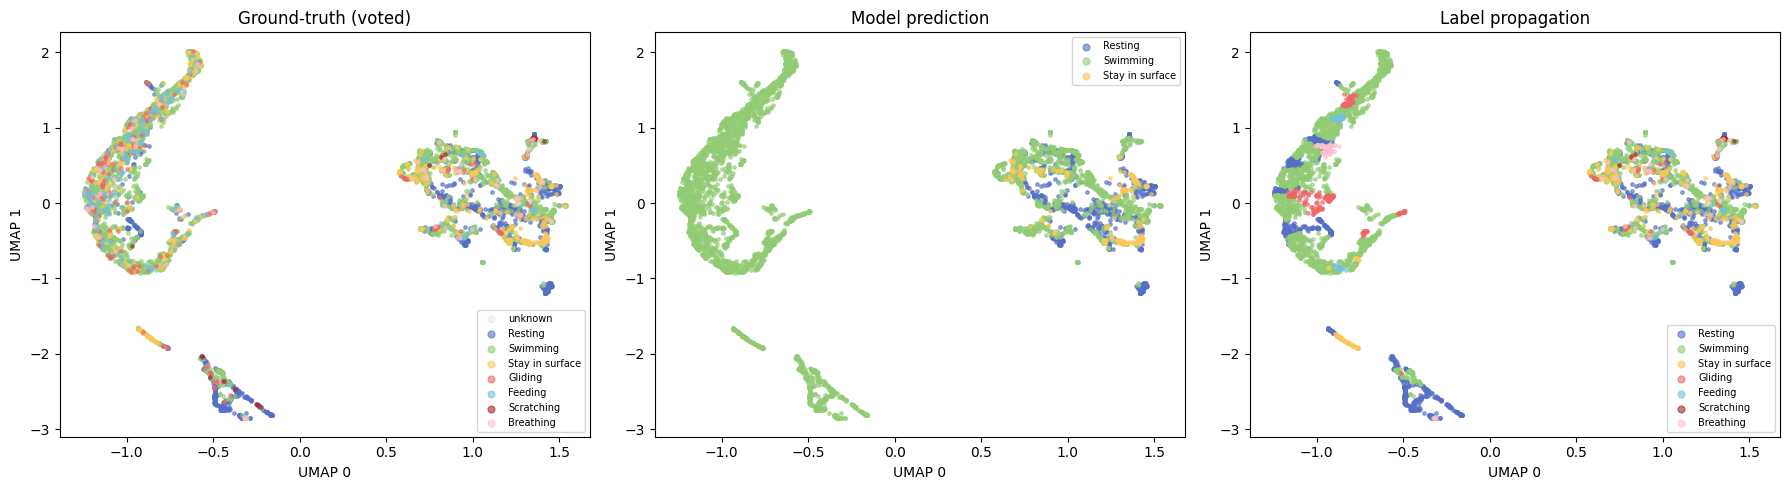

In [13]:
def scatter(ax, xy, labels, title):
    for lab in np.unique(labels):
        if lab < 0:
            m = labels == lab
            ax.scatter(xy[m,0], xy[m,1], s=6, c='lightgrey', alpha=0.3, label='unknown')
        else:
            m = labels == lab
            ax.scatter(xy[m,0], xy[m,1], s=6, alpha=0.6,
                       c=label_colors[int(lab)], label=labeldict_findstr.get(int(lab), str(lab)))
    ax.set_title(title); ax.set_xlabel('UMAP 0'); ax.set_ylabel('UMAP 1')
    ax.legend(markerscale=2, fontsize=7, loc='best')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter(axes[0], data_umap, all_labels, 'Ground-truth (voted)')
scatter(axes[1], data_umap, predictions, 'Model prediction')
scatter(axes[2], data_umap, propagated_labels, 'Label propagation')
plt.tight_layout(); plt.show()

### 5.1 时序标签图：真值(散点) vs 传播标签 / 模型预测(背景色块)

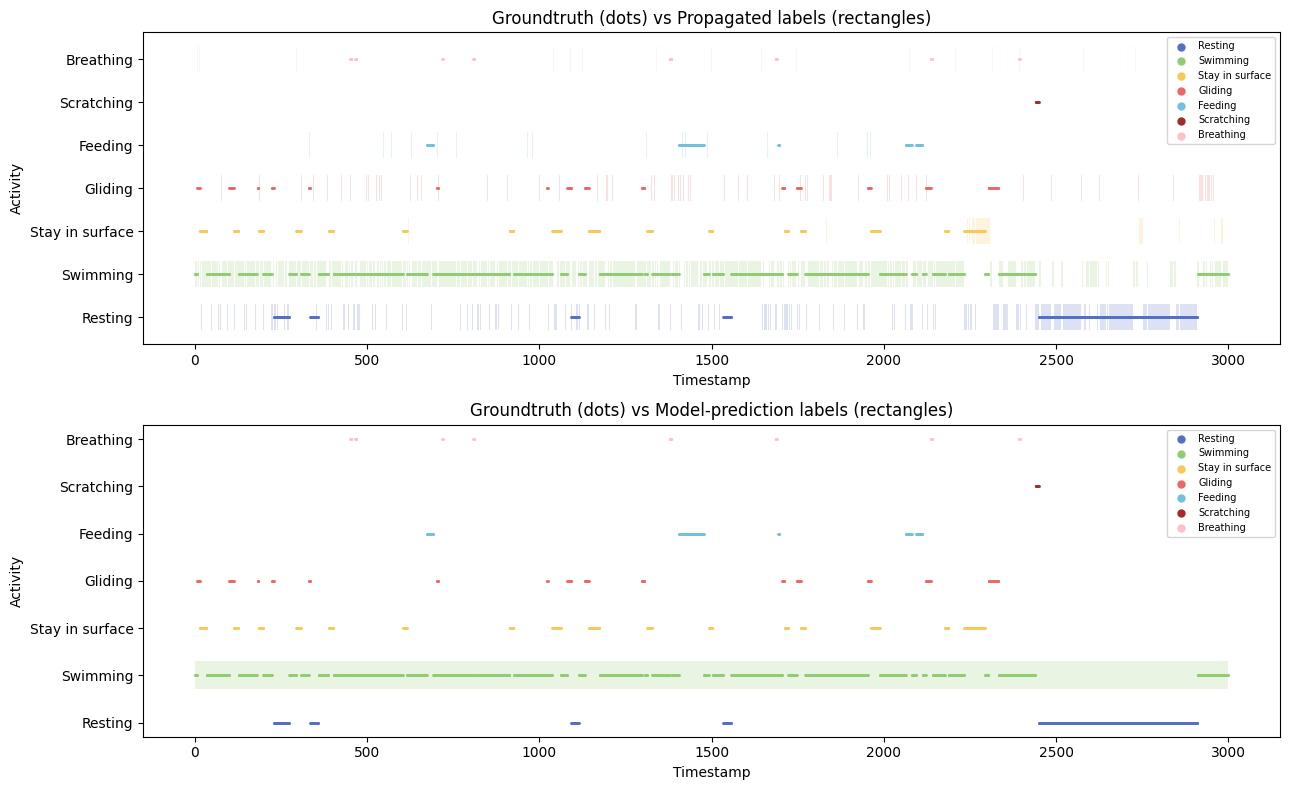

In [14]:
import matplotlib.patches as patches
new_len = len(data_b[startloc:endloc])
true_new = all_labels[-new_len:]
prop_new = propagated_labels[-new_len:]
pred_new = predictions[-new_len:]

def ts_plot(ax, overlay, title):
    for lab, name in labeldict_findstr.items():
        if lab >= 0:
            idx = np.where(true_new == lab)[0]
            ax.scatter(idx, [lab]*len(idx), s=1, color=label_colors[lab], label=name)
    for start in range(0, new_len):
        for lab in np.unique(overlay[start:start+1]):
            if lab >= 0 and lab in label_colors:
                ax.add_patch(patches.Rectangle((start, lab-0.3), 1, 0.6, linewidth=0,
                             facecolor=label_colors[int(lab)], alpha=0.2))
    ax.set_title(title); ax.set_xlabel('Timestamp'); ax.set_ylabel('Activity')
    ax.set_yticks(list(labeldict_wounknown_findstr.keys()))
    ax.set_yticklabels(list(labeldict_wounknown_findstr.values()))
    ax.legend(markerscale=5, fontsize=7, loc='upper right')

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
ts_plot(axes[0], prop_new, 'Groundtruth (dots) vs Propagated labels (rectangles)')
ts_plot(axes[1], pred_new, 'Groundtruth (dots) vs Model-prediction labels (rectangles)')
plt.tight_layout(); plt.show()

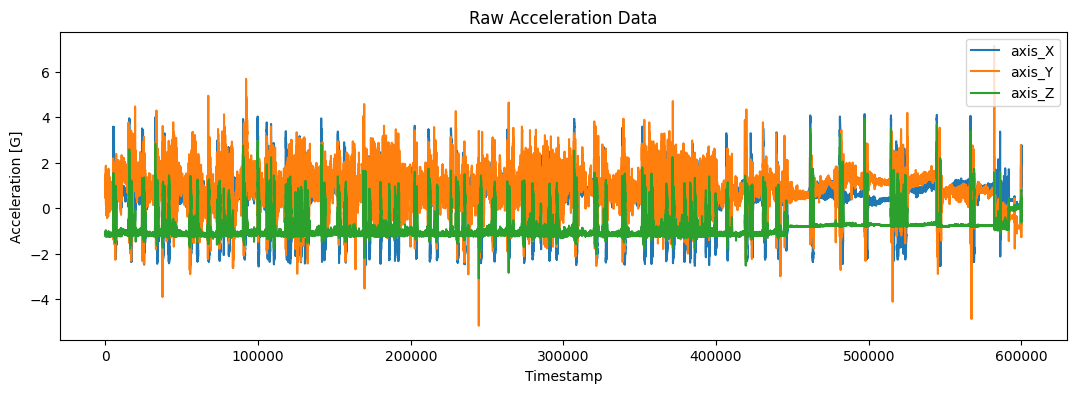

In [15]:
# 原始加速度三轴
plt.figure(figsize=(13,4))
acc = np.concatenate(data_b[startloc:endloc,:3,:].transpose(0,2,1), axis=0)
for i, name in enumerate(['axis_X','axis_Y','axis_Z']):
    plt.plot(acc[:,i], label=name)
plt.xlabel('Timestamp'); plt.ylabel('Acceleration [G]'); plt.title('Raw Acceleration Data')
plt.legend(loc='upper right'); plt.show()

## 6. 小结

- 与 umineko 复现 notebook 结构一致，仅替换数据集与模型（单加速度编码器、7 类、窗口 200）。
- 所有中间结果（数据形状、分布、逐轮指标、特征/UMAP/标签传播）均已内联保留。
- turtle 类别高度不均衡（Swimming 占多数，Scratching/Feeding 稀少），
  Macro-F1 受稀有类影响明显。